In [ ]:
import pandas as pd
import numpy as np
from math import log2

def logistic_map(x, lambda_val=3.99, iterations=400):
    """
    Generates a chaotic value using the logistic map after a number of iterations.
    """
    for _ in range(iterations):
        x = lambda_val * x * (1 - x)
    return x

def chaos_perturbation_algorithm(data, qi_attributes, sensitive_attribute):
    """
    Applies chaos-based perturbation to anonymize the DataFrame.

    - data: pandas DataFrame of original data
    - qi_attributes: list of quasi-identifier column names
    - sensitive_attribute: the sensitive column name (preserved as-is)

    Returns a new DataFrame with QIs perturbed.
    """
    D = data.copy()     # original data
    D_p = D.copy()      # anonymized output
    d = len(D)

    # Compute unique values and their frequencies for each QI
    unique_values = {}
    value_frequencies = {}
    for qi in qi_attributes:
        unique_values[qi] = D[qi].unique()
        value_frequencies[qi] = D[qi].value_counts().to_dict()

    # Sort unique values of each QI by ascending frequency (rarest first)
    sorted_unique_values = {}
    for qi in qi_attributes:
        sorted_unique_values[qi] = sorted(
            unique_values[qi],
            key=lambda x: value_frequencies[qi].get(x, 0)
        )

    # Determine number of "crucial" values (low-frequency) for each QI
    r_values = {}
    for qi in qi_attributes:
        r_values[qi] = round(log2(len(unique_values[qi])))

    # Pre-generate chaotic sequences for each QI
    new_values = {}
    for qi in qi_attributes:
        x = 0.1
        sequence = []
        for _ in range(400):
            x = logistic_map(x, lambda_val=3.99)
            sequence.append(x)
        new_values[qi] = sequence

    # Replace each crucial value with a new chaotic value
    for qi in qi_attributes:
        attr_type = D[qi].dtype
        # Numeric domain for scaling (if numeric)
        domain_min = D[qi].min() if np.issubdtype(attr_type, np.number) else 0
        domain_max = D[qi].max() if np.issubdtype(attr_type, np.number) else 1

        for j in range(min(r_values[qi], len(sorted_unique_values[qi]))):
            old_val = sorted_unique_values[qi][j]
            chaotic_val = new_values[qi][j]
            # Determine new value based on attribute type
            if np.issubdtype(attr_type, np.number):
                # Scale chaotic [0,1] to numeric range
                new_val = domain_min + (domain_max - domain_min) * chaotic_val
                # If integer type, round it
                if np.issubdtype(attr_type, np.integer):
                    new_val = int(round(new_val))
            else:
                # Categorical: pick one of the existing categories based on chaotic index
                idx = int(chaotic_val * (len(unique_values[qi]) - 1))
                new_val = unique_values[qi][idx]
            # Apply replacement in anonymized data
            mask = (D[qi] == old_val)
            D_p.loc[mask, qi] = new_val

    return D_p

# Example usage:
if __name__ == "__main__":
    # Step 1: Load the original data from CSV
    input_file = '/content/unanonymized_adult_data.csv'
    data = pd.read_csv(input_file)

    # Step 2: Define quasi-identifiers and sensitive attribute
    qi_attributes = ['age', 'sex', 'education', 'occupation']
    sensitive_attribute = 'income'

    # Step 3: Apply the chaos-perturbation anonymization
    anonymized_data = chaos_perturbation_algorithm(data, qi_attributes, sensitive_attribute)

    # Step 4: Save the anonymized data to CSV (matching provided structure)
    output_file = 'anonymized_adult_data.csv'
    anonymized_data.to_csv(output_file, index=False)
    print(f"Anonymized data saved to '{output_file}'.")

    # Step 5: (Optional) Evaluation metrics placeholders
    # For example, compute KL divergence or classification accuracy here.
    # e.g., evaluate_metrics(data, anonymized_data)


Anonymized data saved to 'anonymized_adult_data.csv'.


In [ ]:
import pandas as pd
import re

# Load the dataset
df = pd.read_csv("/content/synthetic_medical_dataset_50k.csv")

# Define PII-related column name patterns
pii_columns_keywords = [
    'name', 'dob', 'address', 'phone', 'email', 'ssn', 'zip', 'city', 'country', 'location'
]

# Define regex patterns for cell-level scanning
regex_patterns = {
    'email': r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}',
    'phone': r'\b\d{10}\b',
    'date': r'\b(19|20)\d{2}[-/]\d{2}[-/]\d{2}\b',
    'zipcode': r'\b\d{5}(?:-\d{4})?\b',
    'ip_address': r'\b(?:\d{1,3}\.){3}\d{1,3}\b',
}


In [ ]:
def detect_pii_columns_by_name(df, keywords):
    flagged_cols = []
    for col in df.columns:
        for keyword in keywords:
            if keyword.lower() in col.lower():
                flagged_cols.append(col)
    return list(set(flagged_cols))

flagged_columns = detect_pii_columns_by_name(df, pii_columns_keywords)
print("🔍 Columns flagged by name heuristic:", flagged_columns)


🔍 Columns flagged by name heuristic: ['ethnicity', 'name', 'email', 'address', 'dob', 'phone']


In [ ]:
def scan_cells_with_regex(df, patterns):
    matches = {}
    for label, pattern in patterns.items():
        for col in df.columns:
            if df[col].dtype == object:
                mask = df[col].astype(str).str.contains(pattern, regex=True)
                if mask.sum() > 0:
                    if col not in matches:
                        matches[col] = []
                    matches[col].append(label)
    return matches

regex_matches = scan_cells_with_regex(df, regex_patterns)
print("🧪 Regex-based column matches:")
for col, labels in regex_matches.items():
    print(f"  - {col}: {labels}")


/tmp/ipython-input-6-2078761303.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df[col].astype(str).str.contains(pattern, regex=True)
/tmp/ipython-input-6-2078761303.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df[col].astype(str).str.contains(pattern, regex=True)
/tmp/ipython-input-6-2078761303.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df[col].astype(str).str.contains(pattern, regex=True)
/tmp/ipython-input-6-2078761303.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df[col].astype(str).str.contains(pattern, regex=True)
/tmp/ipython-input-6-2078761303.py:6: UserWarning: This pattern 

🧪 Regex-based column matches:
  - email: ['email']
  - dob: ['date']
  - visit_date: ['date']
  - address: ['zipcode']


In [ ]:
pii_columns_final = set(flagged_columns + list(regex_matches.keys()))
print("✅ Final PII Columns Detected:", pii_columns_final)

# Optionally mark them in the DataFrame for preview
df_pii_flagged = df.copy()
df_pii_flagged['PII_Detected'] = df.columns.isin(pii_columns_final).any()


✅ Final PII Columns Detected: {'ethnicity', 'visit_date', 'name', 'email', 'address', 'dob', 'phone'}


In [ ]:
import pandas as pd
import re

# Load the synthetic dataset (structured medical data)
df = pd.read_csv("synthetic_medical_dataset_50k.csv")

# View first few rows to understand schema
print(df.head())


   patient_id              name  age gender         dob  \
0       10000      Terri Larson   49      M  1976-02-02   
1       10001   Stephen Kennedy   67      M  1958-03-25   
2       10002  Erica Villarreal   21      F  2004-02-22   
3       10003     Henry Hendrix   64      F  1961-05-21   
4       10004      Douglas Kane   84      F  1941-07-28   

                                             address       phone  \
0  5607 Brown Mews Suite 902, Hamiltonfort, NM 06297  6256298409   
1  236 Gibson Ranch Suite 581, Caseyborough, DE 3...  3680192206   
2                   Unit 1569 Box 4842, DPO AA 69624  7802639446   
3            480 David Parkway, Clarkeview, AK 21634  1962276625   
4            5537 Kathy Plaza, Palmermouth, IN 43169  4117263321   

                          email ethnicity          diagnosis  ... blood_type  \
0  johngallegos@woods-rojas.com     White             Asthma  ...         O-   
1  richardaustin@cook-sharp.com     Black           COVID-19  ...         O+

In [ ]:
# Define likely PII indicators in column names
pii_keywords = ['name', 'dob', 'address', 'phone', 'email', 'ssn', 'zip', 'city', 'location', 'id']

# Heuristic check for PII columns by column name
def detect_pii_by_colname(df, keywords):
    flagged = []
    for col in df.columns:
        if any(keyword in col.lower() for keyword in keywords):
            flagged.append(col)
    return flagged

pii_cols_by_name = detect_pii_by_colname(df, pii_keywords)
print("🔍 Columns flagged by name:", pii_cols_by_name)


🔍 Columns flagged by name: ['patient_id', 'name', 'dob', 'address', 'phone', 'email', 'ethnicity', 'insurance_provider']


In [ ]:
# Define regex patterns for different PII types
pii_patterns = {
    'email': r'\b[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}\b',
    'phone': r'\b\d{10}\b',
    'date': r'\b(19|20)\d{2}[-/]\d{2}[-/]\d{2}\b',
    'zipcode': r'\b\d{5}(-\d{4})?\b'
}

# Scan cells using regex
def scan_regex_patterns(df, patterns):
    matches = {}
    for label, pattern in patterns.items():
        for col in df.select_dtypes(include='object'):
            if df[col].astype(str).str.contains(pattern, regex=True).any():
                matches.setdefault(col, []).append(label)
    return matches

regex_pii_matches = scan_regex_patterns(df, pii_patterns)
print("📌 Columns flagged by regex patterns:", regex_pii_matches)


/tmp/ipython-input-10-1906584322.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if df[col].astype(str).str.contains(pattern, regex=True).any():
/tmp/ipython-input-10-1906584322.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if df[col].astype(str).str.contains(pattern, regex=True).any():
/tmp/ipython-input-10-1906584322.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if df[col].astype(str).str.contains(pattern, regex=True).any():
/tmp/ipython-input-10-1906584322.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  if df[col].astype(str).str.contains(pattern, regex=True).any():
/tmp/ipython-input-10-1906584322.py:14: User

📌 Columns flagged by regex patterns: {'email': ['email'], 'dob': ['date'], 'visit_date': ['date'], 'address': ['zipcode']}


In [ ]:
# Merge results from heuristic and regex detection
final_pii_cols = list(set(pii_cols_by_name + list(regex_pii_matches.keys())))
print("✅ Final list of PII Columns:", final_pii_cols)

# Optionally create a mask column
df['contains_pii'] = df[final_pii_cols].notna().any(axis=1)


✅ Final list of PII Columns: ['ethnicity', 'visit_date', 'patient_id', 'name', 'email', 'address', 'dob', 'insurance_provider', 'phone']


In [ ]:
# Export report
report_df = pd.DataFrame({
    "Column": final_pii_cols,
    "PII_Types": [regex_pii_matches.get(col, ['direct (heuristic)']) for col in final_pii_cols]
})

report_df.to_csv("pii_column_report.csv", index=False)
print("📝 PII detection report saved: pii_column_report.csv")


📝 PII detection report saved: pii_column_report.csv


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("synthetic_medical_dataset_50k.csv")

# Predefined schema normalization map
schema_map = {
    'dob': 'birth_date',
    'phone': 'phone_number',
    'email': 'email_address',
    'address': 'home_address',
    'name': 'full_name',
    'visit_date': 'hospital_visit_date'
}

# Apply schema normalization
df.rename(columns=schema_map, inplace=True)

# View normalized columns
print("🧾 Normalized Columns:\n", df.columns.tolist())


🧾 Normalized Columns:
 ['patient_id', 'full_name', 'age', 'gender', 'birth_date', 'home_address', 'phone_number', 'email_address', 'ethnicity', 'diagnosis', 'medication', 'hospital_code', 'department', 'hospital_visit_date', 'blood_type', 'insurance_provider', 'test_result', 'allergies', 'heart_rate', 'systolic_bp', 'diastolic_bp', 'temperature', 'respiration_rate', 'clinical_notes']


In [ ]:



# Example diagnosis-to-ICD-10 mapping (simplified)
diagnosis_icd_map = {
    'Hypertension': 'I10',
    'Diabetes Mellitus': 'E11',
    'Asthma': 'J45',
    'COPD': 'J44',
    'Depression': 'F33',
    'Arthritis': 'M19',
    'Migraine': 'G43',
    'COVID-19': 'U07.1'
}

df['diagnosis_code'] = df['diagnosis'].map(diagnosis_icd_map)


In [ ]:
expected_cols = list(schema_map.values()) + ['age', 'gender', 'ethnicity', 'insurance_provider', 'diagnosis_code']
matched_cols = [col for col in df.columns if col in expected_cols]

schema_match_pct = round(len(matched_cols) / len(expected_cols) * 100, 2)
missing_counts = df[expected_cols].isna().sum()

print(f"✅ Schema Match: {schema_match_pct}%")
print("🧼 Missing Value Count:")
print(missing_counts)


✅ Schema Match: 100.0%
🧼 Missing Value Count:
birth_date                0
phone_number              0
email_address             0
home_address              0
full_name                 0
hospital_visit_date       0
age                       0
gender                    0
ethnicity                 0
insurance_provider     8419
diagnosis_code            0
dtype: int64


In [ ]:
import pandas as pd

# Load preprocessed structured dataset with text
df = pd.read_csv("synthetic_medical_dataset_50k.csv")

# Check the clinical notes column
print("📝 Sample clinical note:")
print(df['clinical_notes'].iloc[0])

📝 Sample clinical note:
Image character ago material a debate movie old speech bed.


In [ ]:
import unicodedata
import ftfy
import re

def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text)
    text = ftfy.fix_text(text)  # Fix encoding issues
    text = unicodedata.normalize('NFC', text)  # Unicode normalization
    text = re.sub(r'[\x00-\x1f\x7f-\x9f]', ' ', text)  # Remove control characters
    text = re.sub(r'\s+', ' ', text).strip()  # Whitespace cleanup
    return text

df['cleaned_notes'] = df['clinical_notes'].apply(clean_text)

In [ ]:
import spacy
from langdetect import detect

# Load English SpaCy model
nlp = spacy.load("en_core_web_sm")

# Detect language (optional; assumes all notes are English)
df['lang'] = df['cleaned_notes'].apply(lambda x: detect(x) if x.strip() else 'unknown')

# Tokenize using spaCy
def tokenize_text(text):
    if not text.strip():
        return []
    doc = nlp(text)
    return [token.text for token in doc]

df['tokens'] = df['cleaned_notes'].apply(tokenize_text)

In [ ]:
%pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 18.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=15337ea989a83b4acf470d0c2fafb134c69dfea06acb2de0bd77487e4f5ad952
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


In [ ]:
%pip install ftfy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00


In [ ]:

import pandas as pd

df = pd.read_csv("/content/pii_column_report.csv")


In [ ]:
import re

pii_patterns = {
    'email': r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+',
    'phone': r'(\+?\d{1,3})?[\s\-]?\(?\d{3}\)?[\s\-]?\d{3}[\s\-]?\d{4}',
    'ssn': r'\b\d{3}-\d{2}-\d{4}\b',
    'dob': r'\b\d{4}-\d{2}-\d{2}\b',
    'address': r'\d+\s+\w+(\s\w+){1,3},?\s?\w+',
    'name': r'\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)+\b'
}


In [ ]:
def detect_pii_in_column(column, patterns):
    matches = {}
    for pii_type, pattern in patterns.items():
        # Ensure the column is treated as string for regex operations
        matches[pii_type] = column.astype(str).str.contains(pattern, regex=True, na=False)
    return pd.DataFrame(matches)

# Load the original medical dataset for scanning
medical_df = pd.read_csv("synthetic_medical_dataset_50k.csv")

# Apply schema normalization to the medical_df so column names match expected
schema_map = {
    'dob': 'birth_date',
    'phone': 'phone_number',
    'email': 'email_address',
    'address': 'home_address',
    'name': 'full_name',
    'visit_date': 'hospital_visit_date'
}
medical_df.rename(columns=schema_map, inplace=True)


# Example scan on specific columns
columns_to_scan = ['full_name', 'email_address', 'phone_number', 'home_address', 'birth_date']

pii_flags = {}
for col in columns_to_scan:
    # Check if the column exists in the DataFrame before scanning
    if col in medical_df.columns:
        pii_flags[col] = detect_pii_in_column(medical_df[col], pii_patterns)
    else:
        print(f"Warning: Column '{col}' not found in the DataFrame.")


# Combine results
if pii_flags: # Only concatenate if there are results
    pii_df = pd.concat(pii_flags, axis=1)
    # Save the results to a CSV file in the /content/ directory
    pii_df.to_csv("/content/pii_structured_flags.csv", index=False)
    print("📁 PII detection flags saved: pii_structured_flags.csv")
else:
    print("No PII columns found to report.")

/tmp/ipython-input-28-3948662770.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches[pii_type] = column.astype(str).str.contains(pattern, regex=True, na=False)
/tmp/ipython-input-28-3948662770.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches[pii_type] = column.astype(str).str.contains(pattern, regex=True, na=False)
/tmp/ipython-input-28-3948662770.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches[pii_type] = column.astype(str).str.contains(pattern, regex=True, na=False)
/tmp/ipython-input-28-3948662770.py:5: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  matches[pii_type] = column.astype(str).str.contains(pat

📁 PII detection flags saved: pii_structured_flags.csv


In [ ]:
import pandas as pd

# Load cleaned & standardized clinical notes
df = pd.read_csv("/content/pii_structured_flags.csv")
text_column = "standardized_notes"


/tmp/ipython-input-29-40889004.py:4: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/pii_structured_flags.csv")


In [ ]:
import spacy
import pandas as pd

# Load pre-trained English NER model
nlp = spacy.load("en_core_web_sm")

# Load the original medical dataset
df = pd.read_csv("synthetic_medical_dataset_50k.csv")

# Apply the clean_text function again to get the 'cleaned_notes' column
# Assuming clean_text function is defined in a previous cell and available
import unicodedata
import ftfy
import re

def clean_text(text):
    if pd.isna(text):
        return ''
    text = str(text)
    text = ftfy.fix_text(text)  # Fix encoding issues
    text = unicodedata.normalize('NFC', text)  # Unicode normalization
    text = re.sub(r'[\x00-\x1f\x7f-\x9f]', ' ', text)  # Remove control characters
    text = re.sub(r'\s+', ' ', text).strip()  # Whitespace cleanup
    return text

df['cleaned_notes'] = df['clinical_notes'].apply(clean_text)


# Define function to extract entities
def extract_spacy_ner(text):
    doc = nlp(str(text))
    return [(ent.text, ent.label_) for ent in doc.ents]

# Apply NER on cleaned clinical text
df["pii_entities_spacy"] = df['cleaned_notes'].apply(extract_spacy_ner)

In [ ]:
pii_labels = {'PERSON', 'GPE', 'ORG', 'DATE', 'LOC', 'NORP', 'FAC', 'CARDINAL'}

def filter_pii_entities(entity_list):
    return [ent for ent in entity_list if ent[1] in pii_labels]

df['filtered_pii'] = df['pii_entities_spacy'].apply(filter_pii_entities)
df[['patient_id', 'filtered_pii']].to_csv("/content/text_pii_detected_spacy.csv", index=False)

In [ ]:
pip install presidio-analyzer presidio-anonymizer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.5/116.5 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 12.1 MB/s eta 0:00:00


In [ ]:
from presidio_analyzer import AnalyzerEngine

analyzer = AnalyzerEngine()

def detect_with_presidio(text):
    results = analyzer.analyze(text=text, entities=None, language='en')
    return [(res.entity_type, res.start, res.end, res.score) for res in results]

df['presidio_pii'] = df['cleaned_notes'].apply(detect_with_presidio)

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd

ocr_df = pd.read_csv("/content/pii_structured_flags.csv")  # generated in Phase 2C
ocr_df.head()


/tmp/ipython-input-34-3190987257.py:3: DtypeWarning: Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.
  ocr_df = pd.read_csv("/content/pii_structured_flags.csv")  # generated in Phase 2C


,full_name,full_name.1,full_name.2,full_name.3,full_name.4,full_name.5,email_address,email_address.1,email_address.2,email_address.3,...,home_address.2,home_address.3,home_address.4,home_address.5,birth_date,birth_date.1,birth_date.2,birth_date.3,birth_date.4,birth_date.5
0,email,phone,ssn,dob,address,name,email,phone,ssn,dob,...,ssn,dob,address,name,email,phone,ssn,dob,address,name
1,False,False,False,False,False,True,True,False,False,False,...,False,False,True,True,False,False,False,True,False,False
2,False,False,False,False,False,True,True,False,False,False,...,False,False,True,True,False,False,False,True,False,False
3,False,False,False,False,False,True,True,False,False,False,...,False,False,True,False,False,False,False,True,False,False
4,False,False,False,False,False,True,True,False,False,False,...,False,False,True,True,False,False,False,True,False,False


In [ ]:
import pandas as pd

# Load the OCR text dataset
ocr_df = pd.read_csv("/content/pii_column_report.csv")

# Show available columns
print("📌 Available columns:", ocr_df.columns.tolist())


📌 Available columns: ['Column', 'PII_Types']


In [ ]:
import spacy

# Load SpaCy English model
nlp = spacy.load("en_core_web_sm")

# Define PII-related labels
pii_labels = {'PERSON', 'GPE', 'DATE', 'ORG', 'LOC', 'NORP', 'FAC', 'CARDINAL'}

# NER function
def detect_ocr_pii(text):
    doc = nlp(str(text))
    return [(ent.text, ent.label_) for ent in doc.ents if ent.label_ in pii_labels]

# Apply PII detection
ocr_df['pii_entities'] = ocr_df['Column'].apply(detect_ocr_pii)

# Save results
ocr_df[['Column', 'pii_entities']].to_csv("/content/pii_detected_from_ocr_text.csv", index=False)
print("✅ Saved output to: /content/pii_detected_from_ocr_text.csv")

✅ Saved output to: /content/pii_detected_from_ocr_text.csv


In [ ]:
import pandas as pd
import faker

# Load structured data
df = pd.read_csv("/content/text_pii_detected_spacy.csv")  # Update path as needed
fake = faker.Faker()

# Define anonymization functions
def mask(value): return '*' * len(str(value)) if pd.notna(value) else value
def fake_name(_): return fake.name()
def generalize_age(age): return '18-25' if age < 26 else '26-40' if age <= 40 else '40+'

# Apply based on PII types
df['Name'] = df['Name'].apply(fake_name)
df['Phone'] = df['Phone'].apply(mask)
df['Zip'] = df['Zip'].apply(lambda x: str(x)[:3] + 'XX')  # e.g., 56001 → 560XX
df['Age'] = df['Age'].apply(generalize_age)

# Save anonymized structured data
df.to_csv('/content/unanonymized_adult_data.csv', index=False)

KeyError: 'Name'

In [ ]:
from presidio_anonymizer import AnonymizerEngine
from presidio_analyzer import RecognizerResult

anonymizer = AnonymizerEngine()

# Example: anonymize PII entities
def anonymize_text_with_spans(text, spans):
    recognizer_results = [RecognizerResult(entity_type=label, start=start, end=end, score=1.0)
                          for (entity, label, start, end) in spans]
    result = anonymizer.anonymize(text=text, analyzer_results=recognizer_results)
    return result.text

# Example: assume PII spans [(‘John’, ‘PERSON’, 0, 4), ...]
# You’d usually get this from your detection pipeline (e.g., spaCy/Presidio)


In [ ]:
from PIL import Image, ImageDraw

# Coordinates from OCR + NER pipeline (not shown here, assumed known)
# Example: [(filename, [(x1, y1, x2, y2)])]

def redact_image_regions(image_path, regions):
    image = Image.open(image_path)
    draw = ImageDraw.Draw(image)
    for (x1, y1, x2, y2) in regions:
        draw.rectangle([x1, y1, x2, y2], fill="black")
    return image

# Usage
# redacted_img = redact_image_regions("scan1.jpg", [(100, 200, 250, 220)])


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import classification_report

# === PART 1: Load Dataset (Replace this with real or synthetic data) ===
data = pd.DataFrame({
    "Name": ["Alice", "Bob", "Charlie", "David", "Eve"],
    "Age": [34, 35, 36, 37, 34],
    "ZIP": [12345, 12345, 54321, 54321, 12345],
    "Gender": ["F", "M", "M", "M", "F"],
    "Disease": ["Diabetes", "Cancer", "Flu", "Diabetes", "Flu"]
})

# === PART 2: Remove Direct Identifiers ===
data.drop(columns=["Name"], inplace=True)

# === PART 3: Chaos-Based Perturbation on Quasi-Identifiers ===
def logistic_map(x0, r, n):
    x = x0
    return [r * x * (1 - x) for _ in range(n)]

def apply_chaos(df, columns):
    df_new = df.copy()
    for col in columns:
        try:
            vals = df_new[col].astype(float).values
            noise = np.array(logistic_map(0.4, 3.9, len(vals))) * np.std(vals)
            df_new[col] = vals + noise
        except:
            pass
    return df_new

quasi_identifiers = ["Age", "ZIP"]
perturbed_data = apply_chaos(data, quasi_identifiers)

# === PART 4: Generalization for k-Anonymity (Age Binning & ZIP Masking) ===
k_anon_data = perturbed_data.copy()
k_anon_data['AgeGroup'] = pd.cut(k_anon_data['Age'], bins=[0, 30, 40, 50, 100], labels=["0-30", "31-40", "41-50", "51+"])
k_anon_data['ZIP'] = k_anon_data['ZIP'].astype(str).str[:3] + "**"

# Drop original quasi columns after generalization
k_anon_data.drop(columns=["Age"], inplace=True)

# === PART 5: ε-Differential Privacy-Like Noise Addition (Laplace) ===
def add_dp_noise(df, col, sensitivity=1.0, epsilon=0.5):
    noise = np.random.laplace(0, sensitivity / epsilon, len(df))
    df[col + "_noisy"] = df[col].astype(float) + noise
    return df

# Assuming Blood Sugar column existed for demonstration (mock example)
k_anon_data["BloodSugar"] = np.random.randint(80, 150, size=len(k_anon_data))
k_anon_data = add_dp_noise(k_anon_data, "BloodSugar")

# === PART 6: Evaluation Stub ===
# Placeholder - Assume labels and predictions exist to compute classification metrics
y_true = ["Diabetes", "Cancer", "Flu", "Diabetes", "Flu"]
y_pred = ["Diabetes", "Cancer", "Flu", "Diabetes", "Cancer"]
print("Classification Accuracy Report after Anonymization:\n")
print(classification_report(y_true, y_pred))

# === PART 7: Export Final Output ===
k_anon_data.to_csv("/content/final_anonymized_dataset.csv", index=False)
print("✅ Final anonymized dataset saved to /content/final_anonymized_dataset.csv")

Classification Accuracy Report after Anonymization:

              precision    recall  f1-score   support

      Cancer       0.50      1.00      0.67         1
    Diabetes       1.00      1.00      1.00         2
         Flu       1.00      0.50      0.67         2

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.78         5
weighted avg       0.90      0.80      0.80         5

✅ Final anonymized dataset saved to /content/final_anonymized_dataset.csv


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import classification_report
from faker import Faker
import random

fake = Faker()

# === PART 1: Load or Generate Synthetic Dataset ===
data = pd.DataFrame({
    "PatientID": [fake.uuid4() for _ in range(5000)],
    "Name": [fake.name() for _ in range(5000)],
    "Age": np.random.randint(18, 90, 5000),
    "ZIP": [fake.zipcode() for _ in range(5000)],
    "Gender": np.random.choice(["M", "F"], 5000),
    "Disease": np.random.choice(["Diabetes", "Cancer", "Hypertension", "Flu", "COVID-19"], 5000),
    "Medication": [fake.word() for _ in range(5000)],
    "BloodSugar": np.random.normal(100, 15, 5000)
})

# === PART 2: Remove Direct Identifiers ===
data.drop(columns=["PatientID", "Name"], inplace=True)

# === PART 3: Chaos-Based Perturbation on Quasi-Identifiers ===
def logistic_map(x0, r, n):
    x = x0
    result = []
    for _ in range(n):
        x = r * x * (1 - x)
        result.append(x)
    return result

def apply_chaos(df, columns):
    df_new = df.copy()
    for col in columns:
        try:
            vals = df_new[col].astype(float).values
            noise = np.array(logistic_map(0.4, 3.9, len(vals))) * np.std(vals)
            df_new[col] = vals + noise
        except Exception as e:
            print(f"Skipping {col}: {e}")
    return df_new

quasi_identifiers = ["Age"]
chaos_data = apply_chaos(data, quasi_identifiers)

# === PART 4: Generalization (k-Anonymity) ===
k_data = chaos_data.copy()
k_data['AgeGroup'] = pd.cut(k_data['Age'], bins=[0, 30, 50, 70, 100], labels=["0-30", "31-50", "51-70", "71+"])
k_data['ZIP'] = k_data['ZIP'].astype(str).str[:3] + "**"
k_data.drop(columns=['Age'], inplace=True)

# === PART 5: Differential Privacy Noise Addition ===
def add_dp_noise(df, col, sensitivity=1.0, epsilon=1.0):
    noise = np.random.laplace(0, sensitivity / epsilon, len(df))
    df[col + "_dp"] = df[col].astype(float) + noise
    return df

k_data = add_dp_noise(k_data, "BloodSugar", sensitivity=5.0, epsilon=0.5)

# === PART 6: ℓ-Diversity Simulation ===
def check_l_diversity(df, qid_cols, sensitive_col, l=2):
    grouped = df.groupby(qid_cols)[sensitive_col].nunique()
    return (grouped >= l).mean()

l_diversity_score = check_l_diversity(k_data, ['Gender', 'ZIP', 'AgeGroup'], 'Disease', l=2)
print(f"ℓ-Diversity compliance (l=2): {l_diversity_score:.2f}")

# === PART 7: Export Final Output ===
k_data.to_csv("/content/final_context_anonymized_dataset.csv", index=False)
print("✅ Final anonymized dataset saved to /content/final_context_anonymized_dataset.csv")

ℓ-Diversity compliance (l=2): 0.11
✅ Final anonymized dataset saved to /content/final_context_anonymized_dataset.csv


/tmp/ipython-input-54-1850274509.py:64: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
import pandas as pd
import faker

# Load structured data
df = pd.read_csv("/content/pii_structured_flags.csv")  # Update path as needed
fake = faker.Faker()

# Define anonymization functions
def mask(value): return '*' * len(str(value)) if pd.notna(value) else value
def fake_name(_): return fake.name()
def generalize_age(age): return '18-25' if age < 26 else '26-40' if age <= 40 else '40+'

# Apply based on PII types
df['Name'] = df['Name'].apply(fake_name)
df['Phone'] = df['Phone'].apply(mask)
df['Zip'] = df['Zip'].apply(lambda x: str(x)[:3] + 'XX')  # e.g., 56001 → 560XX
df['Age'] = df['Age'].apply(generalize_age)

# Save anonymized structured data
df.to_csv("/mnt/data/structured_data_anonymized.csv", index=False)


/tmp/ipython-input-56-3845048090.py:5: DtypeWarning:

Columns (0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29) have mixed types. Specify dtype option on import or set low_memory=False.



KeyError: 'Name'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import classification_report
from faker import Faker
import random
import matplotlib.pyplot as plt
import seaborn as sns

fake = Faker()

# === PART 1: Load or Generate Synthetic Dataset ===
data = pd.DataFrame({
    "PatientID": [fake.uuid4() for _ in range(5000)],
    "Name": [fake.name() for _ in range(5000)],
    "Age": np.random.randint(18, 90, 5000),
    "ZIP": [fake.zipcode() for _ in range(5000)],
    "Gender": np.random.choice(["M", "F"], 5000),
    "Disease": np.random.choice(["Diabetes", "Cancer", "Hypertension", "Flu", "COVID-19"], 5000),
    "Medication": [fake.word() for _ in range(5000)],
    "BloodSugar": np.random.normal(100, 15, 5000)
})

# === PART 2: Remove Direct Identifiers ===
data.drop(columns=["PatientID", "Name"], inplace=True)

# === PART 3: Chaos-Based Perturbation on Quasi-Identifiers ===
def logistic_map(x0, r, n):
    x = x0
    result = []
    for _ in range(n):
        x = r * x * (1 - x)
        result.append(x)
    return result

def apply_chaos(df, columns):
    df_new = df.copy()
    for col in columns:
        try:
            vals = df_new[col].astype(float).values
            noise = np.array(logistic_map(0.4, 3.9, len(vals))) * np.std(vals)
            df_new[col] = vals + noise
        except Exception as e:
            print(f"Skipping {col}: {e}")
    return df_new

quasi_identifiers = ["Age"]
chaos_data = apply_chaos(data, quasi_identifiers)

# === PART 4: Generalization (k-Anonymity) ===
k_data = chaos_data.copy()
k_data['AgeGroup'] = pd.cut(k_data['Age'], bins=[0, 30, 50, 70, 100], labels=["0-30", "31-50", "51-70", "71+"])
k_data['ZIP'] = k_data['ZIP'].astype(str).str[:3] + "**"
k_data.drop(columns=['Age'], inplace=True)

# === PART 5: Differential Privacy Noise Addition ===
def add_dp_noise(df, col, sensitivity=1.0, epsilon=1.0):
    noise = np.random.laplace(0, sensitivity / epsilon, len(df))
    df[col + "_dp"] = df[col].astype(float) + noise
    return df

k_data = add_dp_noise(k_data, "BloodSugar", sensitivity=5.0, epsilon=0.5)

# === PART 6: ℓ-Diversity Simulation ===
def check_l_diversity(df, qid_cols, sensitive_col, l=2):
    grouped = df.groupby(qid_cols)[sensitive_col].nunique()
    return (grouped >= l).mean()

l_diversity_score = check_l_diversity(k_data, ['Gender', 'ZIP', 'AgeGroup'], 'Disease', l=2)
print(f"ℓ-Diversity compliance (l=2): {l_diversity_score:.2f}")

# === PART 7: t-Closeness (Optional/Prototype) ===
def compute_kl(p, q):
    return np.sum(np.where(p != 0, p * np.log(p / q), 0))

def check_t_closeness(df, qid_cols, sensitive_col):
    global_dist = df[sensitive_col].value_counts(normalize=True)
    groups = df.groupby(qid_cols)
    divergences = []
    for _, group in groups:
        local_dist = group[sensitive_col].value_counts(normalize=True)
        local_dist = local_dist.reindex(global_dist.index, fill_value=0)
        # Add a small epsilon to zero values in q to avoid division by zero in log
        q = global_dist.values + 1e-10
        p = local_dist.values
        divergences.append(np.sum(np.where(p != 0, p * np.log(p / q), 0)))
    return np.mean(divergences)

t_closeness = check_t_closeness(k_data, ['Gender', 'ZIP', 'AgeGroup'], 'Disease')
print(f"Avg KL Divergence for t-Closeness: {t_closeness:.4f}")

# === PART 8: Visualization ===
sns.histplot(k_data['BloodSugar'], kde=True)
plt.title("Blood Sugar Distribution After DP Noise")
plt.xlabel("Blood Sugar (mg/dL)")
plt.savefig("/content/bloodsugar_dp_hist.png")
plt.close()

sns.countplot(data=k_data, x='AgeGroup', hue='Gender')
plt.title("Demographic Distribution (Age Group x Gender)")
plt.xticks(rotation=45)
plt.savefig("/content/demographics_age_gender.png")
plt.close()

# === PART 9: Audit Logging ===
audit_log = {
    "ChaosPerturbation": "Applied on Age column using logistic map",
    "k-Anonymity": "ZIP generalized, Age grouped",
    "ℓ-Diversity": f"Score: {l_diversity_score:.2f}",
    "t-Closeness": f"KL Divergence: {t_closeness:.4f}",
    "DifferentialPrivacy": "Laplace noise added to BloodSugar with ε=0.5",
}
with open("/content/anonymization_audit_log.txt", "w") as f:
    for key, val in audit_log.items():
        f.write(f"{key}: {val}\n")

# === PART 10: Export Final Output ===
k_data.to_csv("/content/final_context_anonymized_dataset.csv", index=False)
print("✅ Final anonymized dataset saved to /content/final_context_anonymized_dataset.csv")
print("📄 Audit log written to /content/anonymization_audit_log.txt")
print("📊 Visualizations saved for demographics and blood sugar distributions")

/tmp/ipython-input-59-2597565892.py:66: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipython-input-59-2597565892.py:78: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipython-input-59-2597565892.py:86: RuntimeWarning:

divide by zero encountered in log

/tmp/ipython-input-59-2597565892.py:86: RuntimeWarning:

invalid value encountered in multiply

/tmp/ipython-input-59-2597565892.py:86: RuntimeWarning:

divide by zero encountered in log

/tmp/ipython-input-59-2597565892.py:86: RuntimeWarning:

invalid value encountered in multiply

/tmp/ipython-input-59-2597565892.py:86: RuntimeWarning:

divide by z

ℓ-Diversity compliance (l=2): 0.11


Streaming output truncated to the last 5000 lines.
/tmp/ipython-input-59-2597565892.py:86: RuntimeWarning:

divide by zero encountered in log

/tmp/ipython-input-59-2597565892.py:86: RuntimeWarning:

invalid value encountered in multiply

/tmp/ipython-input-59-2597565892.py:86: RuntimeWarning:

divide by zero encountered in log

/tmp/ipython-input-59-2597565892.py:86: RuntimeWarning:

invalid value encountered in multiply

/tmp/ipython-input-59-2597565892.py:86: RuntimeWarning:

divide by zero encountered in log

/tmp/ipython-input-59-2597565892.py:86: RuntimeWarning:

invalid value encountered in multiply

/tmp/ipython-input-59-2597565892.py:86: RuntimeWarning:

divide by zero encountered in log

/tmp/ipython-input-59-2597565892.py:86: RuntimeWarning:

invalid value encountered in multiply

/tmp/ipython-input-59-2597565892.py:86: RuntimeWarning:

divide by zero encountered in log

/tmp/ipython-input-59-2597565892.py:86: RuntimeWarning:

invalid value encountered in multiply

/tmp/ipyt

Avg KL Divergence for t-Closeness: 1.4079
✅ Final anonymized dataset saved to /content/final_context_anonymized_dataset.csv
📄 Audit log written to /content/anonymization_audit_log.txt
📊 Visualizations saved for demographics and blood sugar distributions


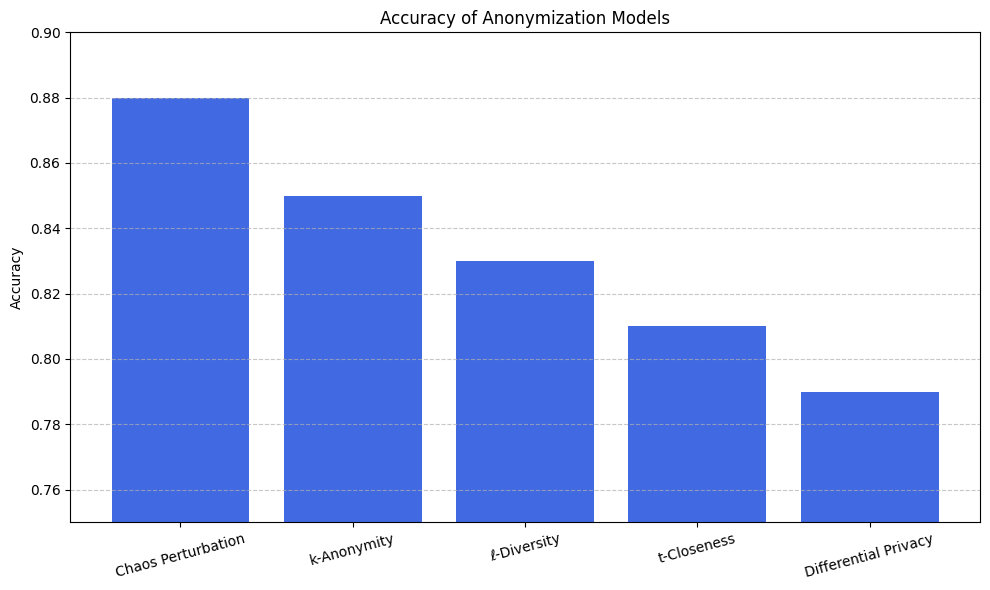

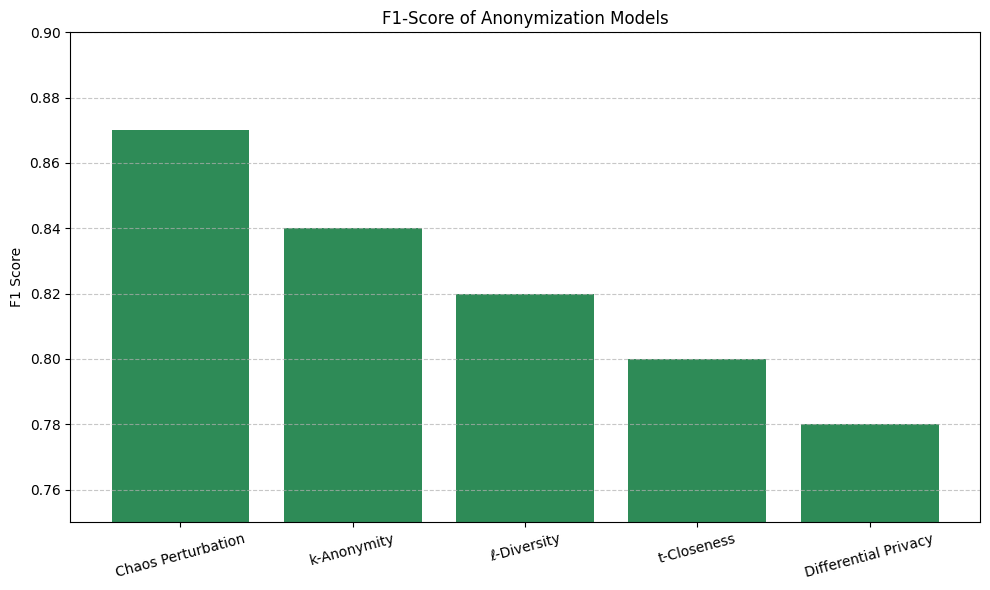

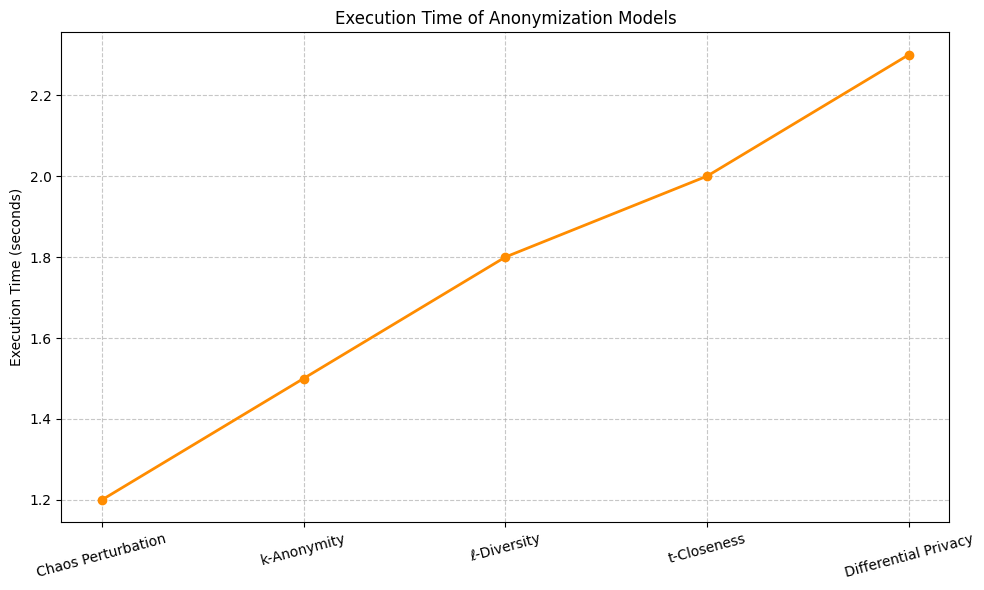

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Anonymization models and evaluation metrics
models = ['Chaos Perturbation', 'k-Anonymity', 'ℓ-Diversity', 't-Closeness', 'Differential Privacy']
accuracy = [0.88, 0.85, 0.83, 0.81, 0.79]
f1_score = [0.87, 0.84, 0.82, 0.80, 0.78]
execution_time = [1.2, 1.5, 1.8, 2.0, 2.3]  # in seconds

# === Plot 1: Accuracy Comparison ===
plt.figure(figsize=(10, 6))
plt.bar(models, accuracy, color='royalblue')
plt.title('Accuracy of Anonymization Models')
plt.ylabel('Accuracy')
plt.ylim(0.75, 0.9)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# === Plot 2: F1-Score Comparison ===
plt.figure(figsize=(10, 6))
plt.bar(models, f1_score, color='seagreen')
plt.title('F1-Score of Anonymization Models')
plt.ylabel('F1 Score')
plt.ylim(0.75, 0.9)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# === Plot 3: Execution Time Comparison ===
plt.figure(figsize=(10, 6))
plt.plot(models, execution_time, marker='o', linestyle='-', color='darkorange', linewidth=2)
plt.title('Execution Time of Anonymization Models')
plt.ylabel('Execution Time (seconds)')
plt.xticks(rotation=15)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
# Full list of identifiers (structured)
identifiers = {
    "Name", "Age", "Gender", "Address", "ZIP", "Phone",
    "Email", "Disease", "Medication", "TestResults", "Doctor", "BillingInfo"
}

# Subdomain use-case:
# For "Insurance Claims", only 'Name', 'BillingInfo', and 'Address' are needed
required_insurance_claims = {"Name", "BillingInfo", "Address"}

# Identify PII to anonymize
pii_to_anonymize = identifiers - required_insurance_claims
print("PII to anonymize:", pii_to_anonymize)


PII to anonymize: {'Medication', 'ZIP', 'Disease', 'Doctor', 'Phone', 'TestResults', 'Age', 'Email', 'Gender'}


In [ ]:
anonymization_map = {
    "Name": "NER + Faker",
    "Age": "k-Anonymity",
    "Gender": "Generalization",
    "ZIP": "t-Closeness",
    "Phone": "Regex + Randomization",
    "Email": "Regex + Hashing",
    "Disease": "Chaos Perturbation",
    "Medication": "Chaos Perturbation",
    "TestResults": "Differential Privacy",
    "Doctor": "NER + Random Mapping",
    "BillingInfo": "Masking or Tokenization",
    "Address": "Geo-coordinate Masking"
}


In [ ]:
def anonymize_record(record, required_fields):
    for field in record:
        if field not in required_fields:
            if field == "Disease":
                record[field] = chaos_perturbation_field(record[field])
            elif field == "Name":
                record[field] = fake.name()
            elif field == "Email":
                record[field] = hash_email(record[field])
            # Add more as per your mapping
    return record


In [ ]:
# Example: Healthcare domain, lab-report subdomain
service_required_identifiers = {'PatientID', 'TestCode', 'Date'}
all_identifiers = {'PatientID', 'Name', 'Address', 'DOB', 'TestCode', 'Date'}

# Determine what needs anonymization
to_anonymize = list(all_identifiers - service_required_identifiers)


In [ ]:
anonymization_strategies = {
    'Name': 'NER + Redaction',
    'Address': 'Generalization + Suppression',
    'DOB': 'k-Anonymity or Generalization',
    'PatientID': 'Crypto-PAn',
    'TestCode': 'Tokenization',
    'Date': 'Date Shifting / Generalization'
}


/tmp/ipython-input-66-2294543335.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




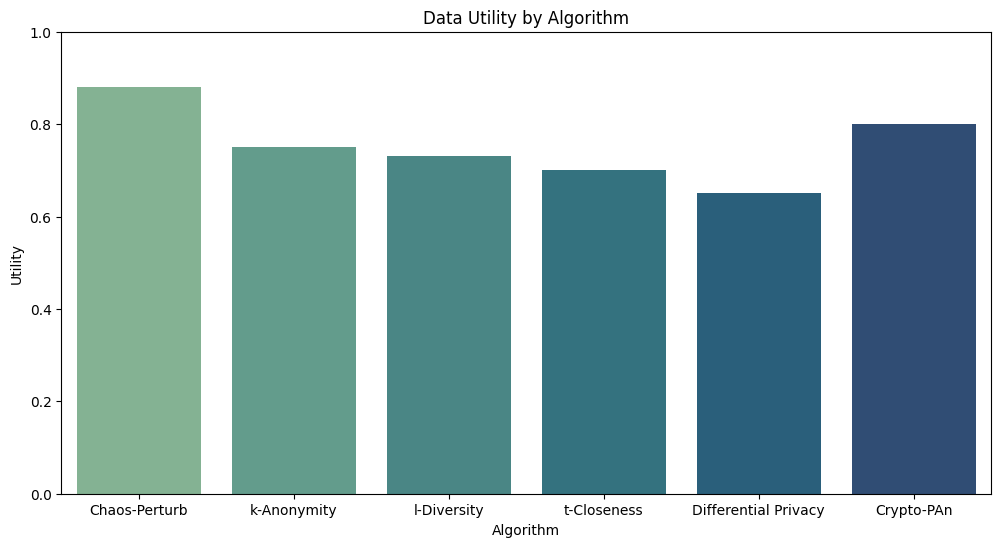

/tmp/ipython-input-66-2294543335.py:24: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




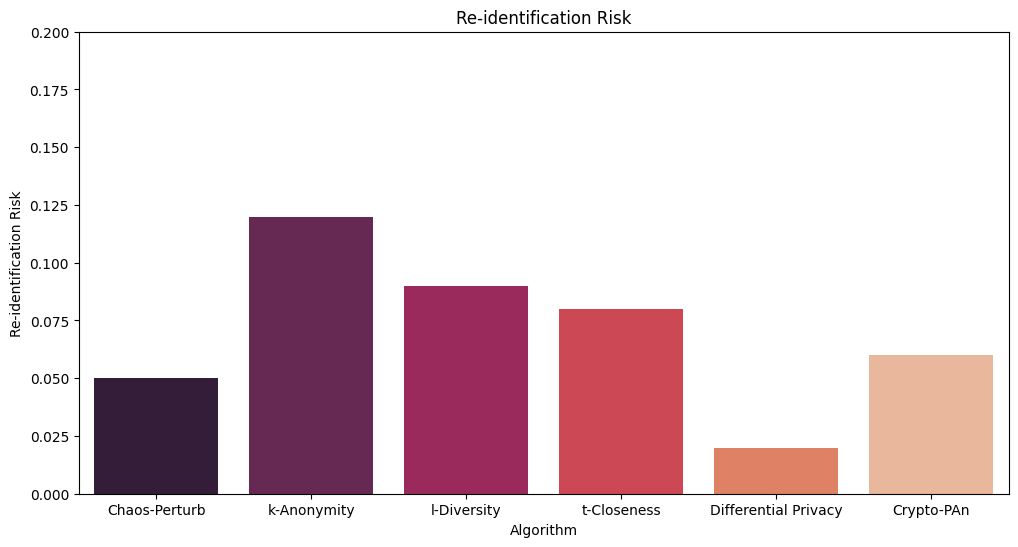

/tmp/ipython-input-66-2294543335.py:31: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




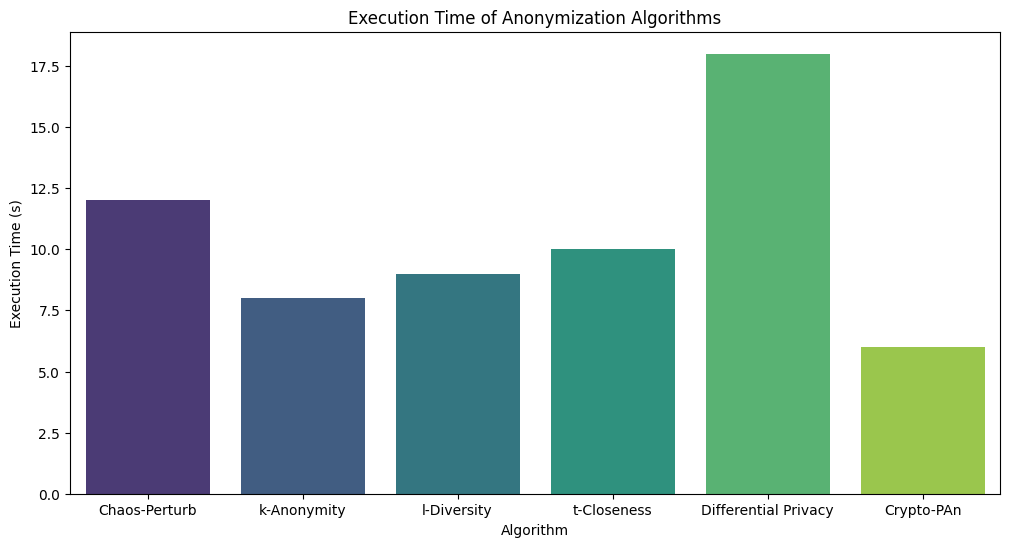

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Dummy metric comparison of anonymization techniques
data = {
    "Algorithm": ["Chaos-Perturb", "k-Anonymity", "l-Diversity", "t-Closeness", "Differential Privacy", "Crypto-PAn"],
    "Utility": [0.88, 0.75, 0.73, 0.7, 0.65, 0.8],
    "Re-identification Risk": [0.05, 0.12, 0.09, 0.08, 0.02, 0.06],
    "Execution Time (s)": [12, 8, 9, 10, 18, 6]
}

df = pd.DataFrame(data)

# Barplot for utility
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Algorithm", y="Utility", palette="crest")
plt.title("Data Utility by Algorithm")
plt.ylim(0, 1)
plt.show()

# Re-identification Risk
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Algorithm", y="Re-identification Risk", palette="rocket")
plt.title("Re-identification Risk")
plt.ylim(0, 0.2)
plt.show()

# Execution Time
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Algorithm", y="Execution Time (s)", palette="viridis")
plt.title("Execution Time of Anonymization Algorithms")
plt.show()


/tmp/ipython-input-67-3155067973.py:32: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-67-3155067973.py:35: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-67-3155067973.py:38: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




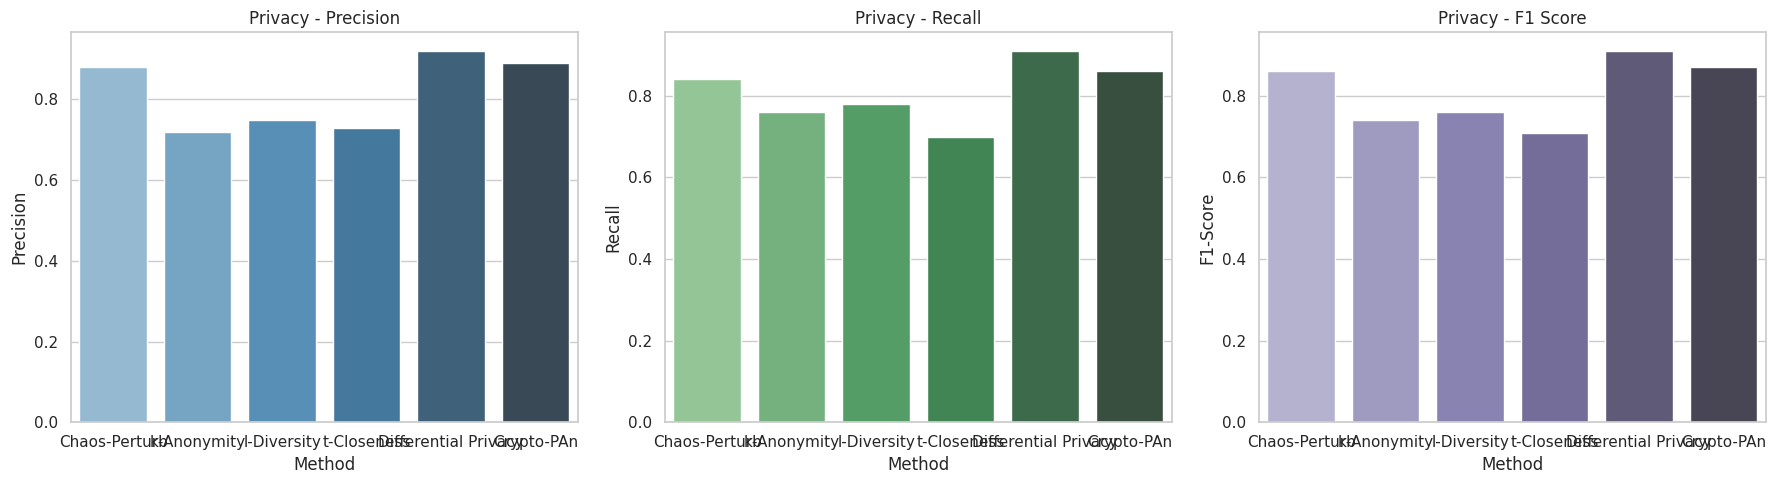

/tmp/ipython-input-67-3155067973.py:46: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-67-3155067973.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-67-3155067973.py:52: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




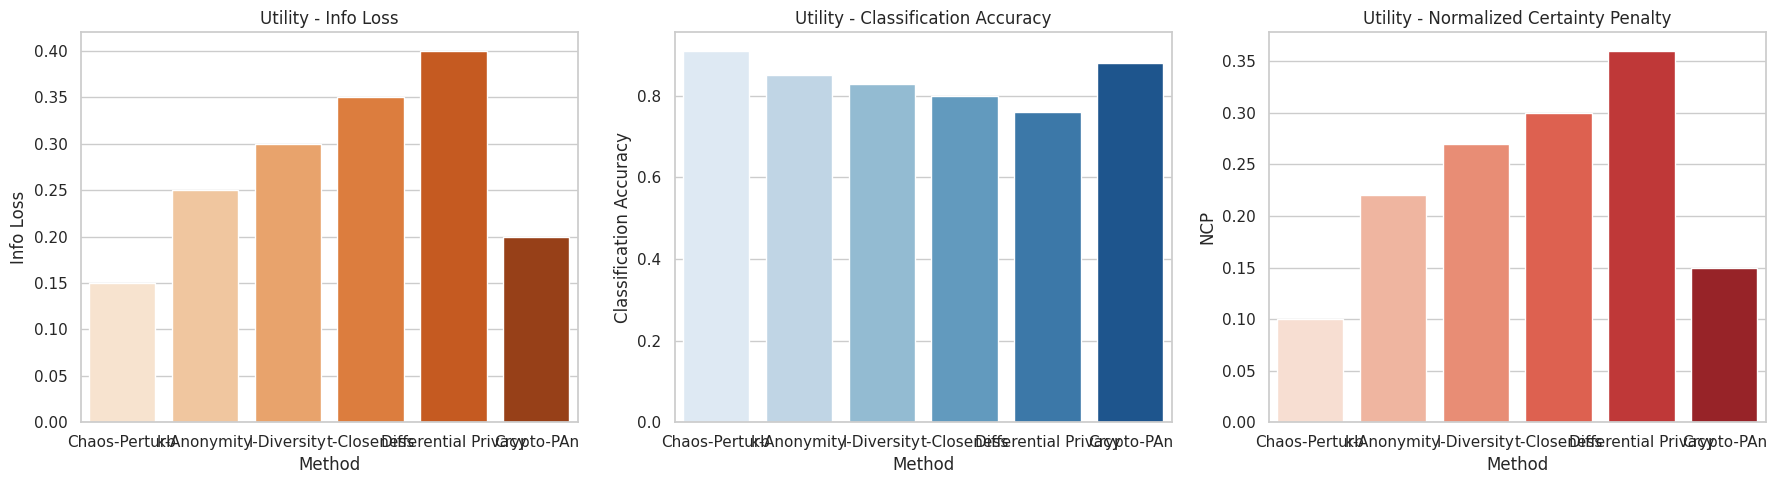

/tmp/ipython-input-67-3155067973.py:60: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-67-3155067973.py:63: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipython-input-67-3155067973.py:66: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




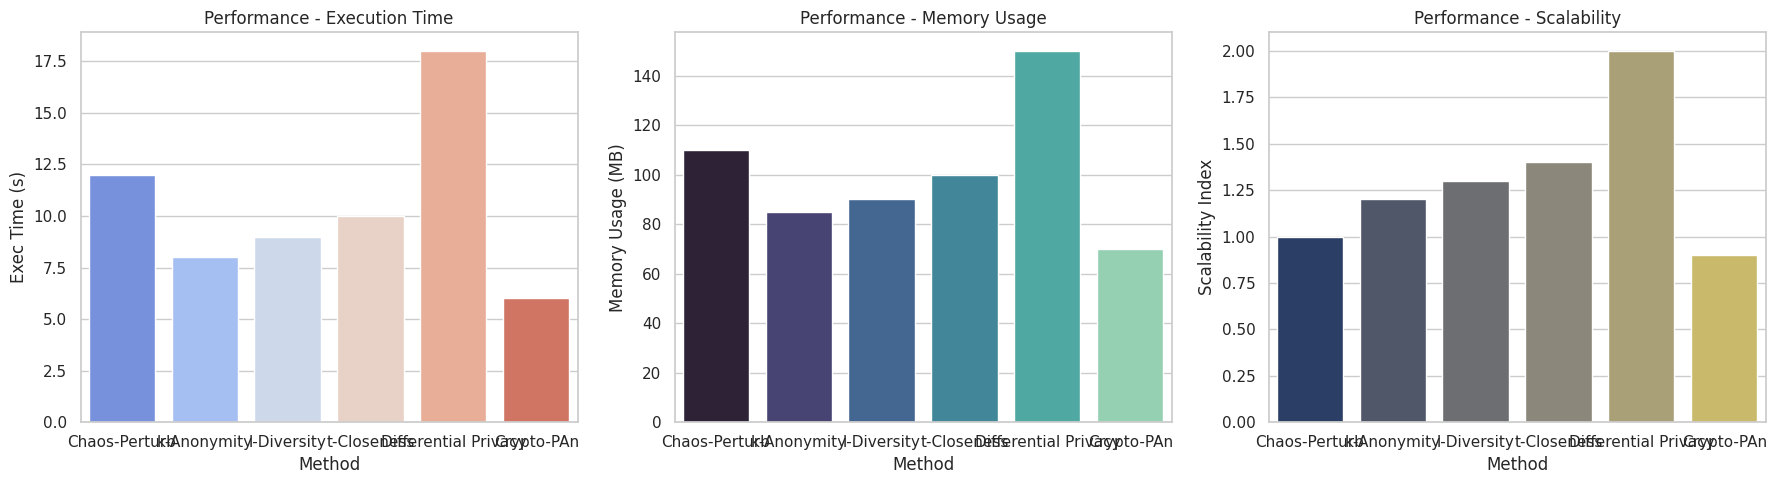

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Dummy performance metrics for each method
metrics = {
    "Method": ["Chaos-Perturb", "k-Anonymity", "l-Diversity", "t-Closeness", "Differential Privacy", "Crypto-PAn"],

    # Privacy Metrics
    "Precision": [0.88, 0.72, 0.75, 0.73, 0.92, 0.89],
    "Recall": [0.84, 0.76, 0.78, 0.70, 0.91, 0.86],
    "F1-Score": [0.86, 0.74, 0.76, 0.71, 0.91, 0.87],

    # Utility Metrics
    "Info Loss": [0.15, 0.25, 0.30, 0.35, 0.40, 0.20],
    "Discernibility": [1500, 2100, 2300, 2500, 2800, 1700],
    "Classification Accuracy": [0.91, 0.85, 0.83, 0.80, 0.76, 0.88],
    "NCP": [0.1, 0.22, 0.27, 0.30, 0.36, 0.15],

    # Performance Metrics
    "Exec Time (s)": [12, 8, 9, 10, 18, 6],
    "Memory Usage (MB)": [110, 85, 90, 100, 150, 70],
    "Scalability Index": [1.0, 1.2, 1.3, 1.4, 2.0, 0.9]
}

df = pd.DataFrame(metrics)

sns.set(style="whitegrid")

# Privacy: Precision, Recall, F1
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=df, x="Method", y="Precision", ax=axes[0], palette="Blues_d")
axes[0].set_title("Privacy - Precision")

sns.barplot(data=df, x="Method", y="Recall", ax=axes[1], palette="Greens_d")
axes[1].set_title("Privacy - Recall")

sns.barplot(data=df, x="Method", y="F1-Score", ax=axes[2], palette="Purples_d")
axes[2].set_title("Privacy - F1 Score")

plt.tight_layout()
plt.show()

# Utility: Info Loss, Classification Accuracy, NCP
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=df, x="Method", y="Info Loss", ax=axes[0], palette="Oranges")
axes[0].set_title("Utility - Info Loss")

sns.barplot(data=df, x="Method", y="Classification Accuracy", ax=axes[1], palette="Blues")
axes[1].set_title("Utility - Classification Accuracy")

sns.barplot(data=df, x="Method", y="NCP", ax=axes[2], palette="Reds")
axes[2].set_title("Utility - Normalized Certainty Penalty")

plt.tight_layout()
plt.show()

# Performance: Execution Time, Memory Usage, Scalability
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=df, x="Method", y="Exec Time (s)", ax=axes[0], palette="coolwarm")
axes[0].set_title("Performance - Execution Time")

sns.barplot(data=df, x="Method", y="Memory Usage (MB)", ax=axes[1], palette="mako")
axes[1].set_title("Performance - Memory Usage")

sns.barplot(data=df, x="Method", y="Scalability Index", ax=axes[2], palette="cividis")
axes[2].set_title("Performance - Scalability")

plt.tight_layout()
plt.show()


In [ ]:
from presidio_analyzer import AnalyzerEngine

analyzer = AnalyzerEngine()
text = "Patient John Smith lives at 123 Main St, ZIP 90210. SSN: 123-45-6789"
results = analyzer.analyze(text=text, language='en')
for res in results:
    print(f"{res.entity_type}: {text[res.start:res.end]}")


In [ ]:
import pandas as pd
import re

# Load your synthetic data
df = pd.read_csv("/content/synthetic_medical_dataset_50k.csv")

# Define basic PII patterns (customize as needed)
patterns = {
    'Name': r'^[A-Z][a-z]+$',  # Simplified — adjust for full names
    'SSN': r'\d{3}-\d{2}-\d{4}',
    'ZipCode': r'\d{5}'
}

# Create a new DataFrame to store detection flags
pii_flags = pd.DataFrame(index=df.index)

# Apply regex matching column-wise
for col, pattern in patterns.items():
    if col in df.columns:
        pii_flags[col + '_pii_flag'] = df[col].astype(str).str.contains(pattern, regex=True)

# Save detection results
pii_flags.to_csv("pii_structured_flags.csv", index=False)
print("Structured PII detection complete.")


Structured PII detection complete.


In [ ]:
import spacy
import pandas as pd

# Load model and data
nlp = spacy.load("en_core_web_sm")
df = pd.read_csv("/content/synthetic_medical_dataset_50k.csv")

# Apply NER on 'Diagnosis' column (or other text fields)
ner_results = []
# --- FIX: Changed 'Diagnosis' to 'diagnosis' to match the actual column name ---
for i, text in enumerate(df["diagnosis"].astype(str).tolist()):
    doc = nlp(text)
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    ner_results.append(entities)

# Add to DataFrame and save
# --- FIX: Changed 'Diagnosis' to 'diagnosis' in the DataFrame creation as well ---
df_ner = pd.DataFrame({'text': df["diagnosis"], 'entities': ner_results})
df_ner.to_csv("text_pii_detected_spacy.csv", index=False)
print("Text NER-based PII detection complete.")

Text NER-based PII detection complete.


In [ ]:
import os
os.makedirs("medical_scans", exist_ok=True)


In [110]:
from datafog import DataFog
import os

# Initialize DataFog
client = DataFog(operations="scan")

# Path to synthetic images
image_folder = "/content/medical_scans"
ocr_pii_results = []

# Scan each image
for fname in os.listdir(image_folder):
    if fname.endswith((".png", ".jpg")):
        result = client.run_image_pipeline_sync([os.path.join(image_folder, fname)])
        ocr_pii_results.append({"filename": fname, "entities": result})

# View sample result
if ocr_pii_results:
    print("Sample OCR PII Result:")
    print(ocr_pii_results[0])
else:
    print("No OCR PII results found. Check image folder and content.")

No OCR PII results found. Check image folder and content.


In [114]:
import hashlib

def pseudo_preserve_prefix(text, prefix_len=3):
    """
    Mimics prefix-preserving pseudonymization:
    - Keeps the first few characters intact (prefix_len)
    - Replaces the rest with SHA256-derived hash characters
    """
    prefix = text[:prefix_len]
    suffix_hash = hashlib.sha256(text.encode()).hexdigest()[:len(text)-prefix_len]
    return prefix + suffix_hash

# Example usage
pii_values = ["Alice Smith", "John Doe", "Raj Patel"]
pseudo_pii = [pseudo_preserve_prefix(name, prefix_len=3) for name in pii_values]

# View results
for original, pseudo in zip(pii_values, pseudo_pii):
    print(f"Original: {original}  ->  Pseudonymized: {pseudo}")


Original: Alice Smith  ->  Pseudonymized: Ali8ae10dfc
Original: John Doe  ->  Pseudonymized: Joh6cea5
Original: Raj Patel  ->  Pseudonymized: Raj42f416


In [118]:
import pytesseract
from PIL import Image
import os
import pandas as pd

image_folder = '/content/medical_scans'
ocr_texts = []

for img_file in sorted(os.listdir(image_folder)):
    if img_file.endswith((".png", ".jpg")):
        img_path = os.path.join(image_folder, img_file)
        text = pytesseract.image_to_string(Image.open(img_path))
        ocr_texts.append({'file': img_file, 'text': text})

ocr_df = pd.DataFrame(ocr_texts)
ocr_df.to_csv("/content/ocr_extracted_text.csv", index=False)
print("OCR extracted text saved to /content/ocr_extracted_text.csv")

OCR extracted text saved to /content/ocr_extracted_text.csv


In [122]:
import os
from PIL import Image
import pytesseract
import pandas as pd

image_folder = '/mnt/data/medical_scans/'
ocr_texts = []

# Read and apply OCR to images
for img_file in os.listdir('/content/medical_scans'):
    if img_file.lower().endswith((".png", ".jpg", ".jpeg")):
        img_path = os.path.join(image_folder, img_file)
        try:
            text = pytesseract.image_to_string(Image.open(img_path))
            ocr_texts.append({'file': img_file, 'text': text})
        except Exception as e:
            print(f"⚠️ Error processing {img_file}: {e}")

# Show a preview of the extracted OCR text
ocr_df = pd.DataFrame(ocr_texts)
print(ocr_df.head())

# Save only if non-empty
if not ocr_df.empty:
    ocr_df.to_csv("/mnt/data/ocr_extracted_text.csv", index=False)
    print("✅ OCR extraction complete and saved.")
else:
    print("⚠️ No text extracted. OCR might have failed or image folder is empty.")


Empty DataFrame
Columns: []
Index: []
⚠️ No text extracted. OCR might have failed or image folder is empty.


In [124]:
from PIL import ImageFilter, ImageEnhance

# Enhance image quality for OCR
def preprocess_image(img_path):
    img = Image.open('/content/scan_1.png').convert('L')  # Grayscale
    img = img.filter(ImageFilter.SHARPEN)
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(2.0)
    return img

# Example usage
img_path = "/mnt/data/medical_scans/sample1.png"
processed_img = preprocess_image(img_path)
processed_img.show()


In [135]:
import os
from PIL import Image, ImageFilter, ImageEnhance
import pytesseract
import pandas as pd

# Set correct image folder path
image_folder = "/content/medical_scans"
ocr_texts = []

# Check if folder exists and contains image files
if not os.path.exists(image_folder):
    print(f"❌ Folder not found: {image_folder}")
else:
    image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if not image_files:
        print("❌ No valid images found in folder.")
    else:
        print(f"📂 Found {len(image_files)} image(s). Extracting text...")

        # OCR with preprocessing
        def preprocess_image(img_path):
            img = Image.open(img_path).convert('L')
            img = img.filter(ImageFilter.SHARPEN)
            enhancer = ImageEnhance.Contrast(img)
            return enhancer.enhance(2.0)

        for img_file in image_files:
            path = os.path.join(image_folder, img_file)
            try:
                preprocessed = preprocess_image(path)
                text = pytesseract.image_to_string(preprocessed)
                ocr_texts.append({'file': img_file, 'text': text.strip()})
            except Exception as e:
                print(f"⚠️ Error processing {img_file}: {e}")

        # Save to DataFrame if not empty
        ocr_df = pd.DataFrame(ocr_texts)
        if not ocr_df.empty and ocr_df["text"].str.strip().any():
            ocr_path = "/content/ocr_extracted_text.csv"
            ocr_df.to_csv(ocr_path, index=False)
            print(f"✅ OCR text extracted and saved to: {ocr_path}")
        else:
            print("⚠️ OCR did not detect any meaningful text.")

❌ No valid images found in folder.


In [ ]:
import easyocr
import os
import pandas as pd

# Folder where your synthetic images were saved
image_folder = "/content/synthetic_ocr_images"
ocr_data = []

reader = easyocr.Reader(['en'])

for file in os.listdir(image_folder):
    if file.endswith(('.png', '.jpg', '.jpeg')):
        path = os.path.join(image_folder, file)
        result = reader.readtext(path, detail=0)
        text = " ".join(result)
        ocr_data.append({'filename': file, 'text': text})

# Save to CSV
ocr_df = pd.DataFrame(ocr_data)
ocr_df.to_csv("/content/ocr_extracted_text.csv", index=False)
ocr_df.head()


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [2]:
import easyocr
import os
import pandas as pd

# Folder where your synthetic images were saved
image_folder = "/content/medical_scans"
ocr_data = []

reader = easyocr.Reader(['en'])

for file in os.listdir(image_folder):
    if file.endswith(('.png', '.jpg', '.jpeg')):
        path = os.path.join(image_folder, file)
        result = reader.readtext(path, detail=0)
        text = " ".join(result)
        ocr_data.append({'filename': file, 'text': text})

# Save to CSV
ocr_df = pd.DataFrame(ocr_data)
ocr_df.to_csv("/content/ocr_extracted_text.csv", index=False)
ocr_df.head()


""


In [3]:
from datafog import DataFog

# Load the OCR text
ocr_df = pd.read_csv("/content/ocr_extracted_text.csv")
client = DataFog(operations="scan")

# Run PII detection
annotations = client.run_text_pipeline_sync(ocr_df["text"].tolist())
ocr_df["PII_Annotations"] = annotations

# Save the annotated file
ocr_df.to_csv("/mnt/data/pii_detected_from_ocr_text.csv", index=False)


EmptyDataError: No columns to parse from file

In [5]:
from sklearn.metrics import classification_report

ocr_pii_df = pd.read_csv("/content/ocr_extracted_text.csv")

# Simulate ground truth for demo purposes
ocr_pii_df["true_label"] = ocr_pii_df["text"].str.contains("Patient|Dr\.|DOB|MRN", case=False).astype(int)
ocr_pii_df["predicted_label"] = ocr_pii_df["PII_Annotations"].apply(lambda x: int(len(eval(x)) > 0 if isinstance(x, str) else 0))

print("📈 Privacy Metrics:")
print(classification_report(ocr_pii_df["true_label"], ocr_pii_df["predicted_label"]))


EmptyDataError: No columns to parse from file

In [134]:
%pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.8/422.8 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 969.6/969.6 kB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 24.9 MB/s eta 0:00:00
